<a href="https://colab.research.google.com/github/Ananyaya17/Hindi-Image-Captioning-/blob/main/newmod_ic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully!")

Sun Nov 30 10:02:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os, zipfile, shutil

# Path to your dataset zip file in Drive
zip_path = '/content/drive/My Drive/data.zip'
extract_path = '/content'

print("Extracting data.zip...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✓ Data extracted successfully!")

# Handle "archive (1)" folder automatically
archive_folder = '/content/archive (1)'
if os.path.exists(archive_folder):
    print(f"✓ Found archive folder: {archive_folder}")

    # Move Images_all folder
    src_images = os.path.join(archive_folder, 'Images_all')
    dst_images = '/content/Images_all'
    if os.path.exists(src_images):
        if os.path.exists(dst_images): shutil.rmtree(dst_images)
        shutil.move(src_images, dst_images)
        print("✓ Moved Images_all to /content/")

    # Move captions file
    src_captions = os.path.join(archive_folder, 'Clean-5Sentences_withComma.txt')
    dst_captions = '/content/Clean-5Sentences_withComma.txt'
    if os.path.exists(src_captions):
        if os.path.exists(dst_captions): os.remove(dst_captions)
        shutil.move(src_captions, dst_captions)
        print("✓ Moved Clean-5Sentences_withComma.txt to /content/")

    # Clean up
    shutil.rmtree(archive_folder, ignore_errors=True)
    print("✓ Cleaned up temporary files")

# Verify
image_folder = '/content/Images_all'
captions_file = '/content/Clean-5Sentences_withComma.txt'
print(f"\n✓ Images folder exists: {os.path.exists(image_folder)}")
print(f"✓ Captions file exists: {os.path.exists(captions_file)}")

if os.path.exists(image_folder):
    num_images = len(os.listdir(image_folder))
    print(f"✓ Total images: {num_images}")
    print(f"✓ Sample images: {os.listdir(image_folder)[:3]}")

if os.path.exists(captions_file):
    with open(captions_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    print(f"✓ Total caption lines: {len(lines)}")
    if len(lines) > 1:
        print(f"✓ First caption line sample:\n{lines[1][:120]}")


Extracting data.zip...
✓ Data extracted successfully!
✓ Found archive folder: /content/archive (1)
✓ Moved Images_all to /content/
✓ Moved Clean-5Sentences_withComma.txt to /content/
✓ Cleaned up temporary files

✓ Images folder exists: True
✓ Captions file exists: True
✓ Total images: 8091
✓ Sample images: ['2250870111_8402d2319d.jpg', '654130822_4aeb1f1273.jpg', '3014986976_0e7b858970.jpg']
✓ Total caption lines: 40451
✓ First caption line sample:
1000268201_693b08cb0e,गुलाबी पोशाक में बच्चा प्रवेश के रास्ते में सीढ़ियों के सेट पर चढ़ रहा है।



In [ ]:
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# ✅ Step 1: Build the InceptionV3 encoder
def build_incep_encoder():
    base_model = InceptionV3(weights="imagenet")
    model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
    return model

# ✅ Step 2: Extract features for one image
def extract_features_incep(img_path, model):
    try:
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        feature = model.predict(x, verbose=0)
        return feature
    except Exception as e:
        print(f"⚠️ Skipping {img_path}: {e}")
        return None

# ✅ Step 3: Extract features for all images
image_folder = "/content/Images_all"
output_path = "/content/image_features_incep.npy"

incep_model = build_incep_encoder()
print("✅ InceptionV3 model loaded for feature extraction.")

features = {}
all_images = os.listdir(image_folder)

for img_name in tqdm(all_images, desc="Extracting Inception features"):
    img_path = os.path.join(image_folder, img_name)
    feature = extract_features_incep(img_path, incep_model)
    if feature is not None:
        features[img_name.split(".")[0]] = feature  # store without extension

np.save(output_path, features)
print(f"\n✅ Features extracted for {len(features)} images and saved to {output_path}")


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ InceptionV3 model loaded for feature extraction.


Extracting Inception features:  29%|██▉       | 2358/8091 [03:20<08:08, 11.75it/s]


KeyboardInterrupt: 

In [ ]:
!ls /content


In [ ]:
import numpy as np
import pickle
import os
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ✅ Load tokenizer
with open("/content/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
vocab_size = len(tokenizer.word_index) + 1
max_length = 37
print(f"✅ Tokenizer loaded. Vocab size: {vocab_size}")

# ✅ Load InceptionV3 extracted image features
features = np.load("/content/image_features_incep.npy", allow_pickle=True).item()
print(f"✅ Image features loaded: {len(features)} images")

# ✅ Load captions file
captions_file = "/content/Clean-5Sentences_withComma.txt"
captions = {}
with open(captions_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if len(line) < 1:
            continue
        img, caption = line.split(',', 1)
        if img not in captions:
            captions[img] = []
        captions[img].append("startseq " + caption.strip() + " endseq")

print(f"✅ Captions loaded: {len(captions)} images")

# ✅ Prepare training data
X1train, X2train, ytrain = list(), list(), list()

for key, desc_list in captions.items():
    if key not in features:
        continue
    feature = features[key][0] if isinstance(features[key], np.ndarray) and len(features[key].shape) > 1 else features[key]
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1train.append(feature)
            X2train.append(in_seq)
            ytrain.append(out_seq)

X1train = np.array(X1train)
X2train = np.array(X2train)
ytrain = np.array(ytrain)

print("\n✅ Data ready for training!")
print(f"🔸 X1 shape: {X1train.shape}")
print(f"🔸 X2 shape: {X2train.shape}")
print(f"🔸 y shape: {ytrain.shape}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/tokenizer.pkl'

In [ ]:
import pickle
import numpy as np

# ✅ Load tokenizer
with open("/content/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
print("✅ Tokenizer loaded successfully!")

# ✅ Define vocab size and max length (from previous preprocessing)
vocab_size = len(tokenizer.word_index) + 1
max_length = 37  # You already computed this during preprocessing

print(f"🔹 Vocabulary size: {vocab_size}")
print(f"🔹 Max caption length: {max_length}")


✅ Tokenizer loaded successfully!
🔹 Vocabulary size: 10035
🔹 Max caption length: 37


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ✅ Step 1: Define Optimized Model Architecture
def build_incep_caption_optimized(vocab_size, max_length):
    # Image feature input branch
    inputs1 = Input(shape=(2048,), name="image_features")
    fe1 = Dense(512, activation='relu')(inputs1)
    fe1 = Dropout(0.4)(fe1)

    # Caption input branch
    inputs2 = Input(shape=(max_length,), name="caption_input")
    se1 = Embedding(vocab_size, 256)(inputs2)
    se2 = LSTM(512, return_sequences=False, dropout=0.3)(se1)

    # Merge branches
    decoder1 = Add()([fe1, se2])
    decoder1 = LayerNormalization()(decoder1)
    decoder2 = Dense(512, activation='relu')(decoder1)
    decoder2 = Dropout(0.4)(decoder2)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    return model

# ✅ Step 2: Compile model
model = build_incep_caption_optimized(vocab_size, max_length)
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)
model.summary()

# ✅ Step 3: Set up Callbacks
checkpoint = ModelCheckpoint(
    '/content/best_incep_caption_model2.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ✅ Step 4: Train Model (20 Epochs)
history = model.fit(
    [X1train, X2train],
    ytrain,
    epochs=20,
    batch_size=256,
    validation_split=0.15,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

# ✅ Step 5: Plot Training Curves
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model 2 - Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model 2 - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │  1,049,088 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 37, 256)   │  2,568,960 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 512)       │  1,574,912 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512)       │      1,024 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    262,656 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10035)     │  5,147,955 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,604,595 (40.45 MB)

 Trainable params: 10,604,595 (40.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ✅ Step 1: Define optimized model
def build_incep_caption_optimized(vocab_size, max_length):
    inputs1 = Input(shape=(2048,), name="image_features")
    fe1 = Dense(512, activation='relu')(inputs1)
    fe1 = Dropout(0.4)(fe1)

    inputs2 = Input(shape=(max_length,), name="caption_input")
    se1 = Embedding(vocab_size, 256)(inputs2)
    se2 = LSTM(512, return_sequences=False, dropout=0.3)(se1)

    decoder1 = Add()([fe1, se2])
    decoder1 = LayerNormalization()(decoder1)
    decoder2 = Dense(512, activation='relu')(decoder1)
    decoder2 = Dropout(0.4)(decoder2)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    return model

# ✅ Step 2: Build and compile
model = build_incep_caption_optimized(vocab_size, max_length)
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=3e-4), metrics=['accuracy'])
model.summary()

# ✅ Step 3: Callbacks
checkpoint = ModelCheckpoint(
    '/content/best_incep_caption_model2.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ✅ Step 4: Train (20 epochs, 15% validation)
history = model.fit(
    [X1train, X2train],
    ytrain,
    epochs=20,
    batch_size=256,
    validation_split=0.15,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

# ✅ Step 5: Plot training history
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model 2 Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  2,568,960 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  1,574,912 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout[0][0],    │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512)       │      1,024 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10035)     │  5,147,955 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,604,595 (40.45 MB)

 Trainable params: 10,604,595 (40.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Load pre-trained InceptionV3 model
def build_incep_encoder():
    model = InceptionV3(weights='imagenet')
    model = Model(model.input, model.layers[-2].output)
    return model

def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x, verbose=0)
    return features

# Load encoder once
incep_model = build_incep_encoder()
print("✅ InceptionV3 Encoder ready.")


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ InceptionV3 Encoder ready.


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Recreate tokenizer from your cleaned captions file
captions_list = []

with open("/content/Clean-5Sentences_withComma.txt", "r", encoding="utf-8") as f:
    for line in f:
        if "," not in line:
            continue
        _, caption = line.strip().split(",", 1)
        captions_list.append(f"startseq {caption.strip()} endseq")

# Create and fit tokenizer
tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(captions_list)

# Save tokenizer for reuse
with open("/content/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

vocab_size = len(tokenizer.word_index) + 1
print(f"✅ Tokenizer created and saved! Vocabulary size = {vocab_size}")


✅ Tokenizer created and saved! Vocabulary size = 10035


In [ ]:
# Load your tokenizer
with open("/content/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

vocab_size = len(tokenizer.word_index) + 1
print("✅ Tokenizer loaded. Vocabulary size:", vocab_size)

# Load preprocessed captions dictionary
captions_path = "/content/captions_dict.json"
if not os.path.exists(captions_path):
    # Recreate if missing
    captions_dict = {}
    with open("/content/Clean-5Sentences_withComma.txt", "r", encoding="utf-8") as f:
        for line in f:
            if "," not in line:
                continue
            img_id, caption = line.strip().split(",", 1)
            img_id = img_id.split(".")[0]
            caption = f"startseq {caption.strip()} endseq"
            captions_dict.setdefault(img_id, []).append(caption)
    with open(captions_path, "w", encoding="utf-8") as f:
        json.dump(captions_dict, f, ensure_ascii=False, indent=2)
else:
    with open(captions_path, "r", encoding="utf-8") as f:
        captions_dict = json.load(f)

print("✅ Captions dictionary loaded. Total images:", len(captions_dict))


✅ Tokenizer loaded. Vocabulary size: 10035
✅ Captions dictionary loaded. Total images: 8091


In [ ]:
# Load extracted image features
features = np.load("/content/image_features_incep.npy", allow_pickle=True).item()

# Maximum caption length
max_length = max(len(caption.split()) for caps in captions_dict.values() for caption in caps)
print("✅ Max caption length:", max_length)

# Data preparation (encoder-decoder)
X1train, X2train, ytrain = list(), list(), list()

for key, captions_list in tqdm(captions_dict.items()):
    if key not in features:
        continue
    feature = features[key][0]
    for caption in captions_list:
        seq = tokenizer.texts_to_sequences([caption])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = np.pad(in_seq, (max_length - len(in_seq), 0), mode='constant')
            out_seq = np.zeros(vocab_size)
            out_seq[out_seq == 0] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq] = 0
            out_seq[out_seq == out_seq


SyntaxError: incomplete input (ipython-input-1571550288.py, line 266)

In [ ]:
# ===========================================
# STEP 1 — IMPORT LIBRARIES
# ===========================================
import numpy as np
import os, json, pickle
from tqdm import tqdm
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from nltk.translate.bleu_score import corpus_bleu

# ===========================================
# STEP 2 — BUILD INCEPTIONV3 FEATURE EXTRACTOR
# ===========================================
def build_incep_encoder():
    model = InceptionV3(weights='imagenet')
    model = Model(model.input, model.layers[-2].output)
    return model

def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x, verbose=0)
    return features

print("✅ InceptionV3 Encoder ready.")

# ===========================================
# STEP 3 — RECREATE TOKENIZER (if missing)
# ===========================================
tokenizer_path = "/content/tokenizer.pkl"

if not os.path.exists(tokenizer_path):
    captions_list = []
    with open("/content/Clean-5Sentences_withComma.txt", "r", encoding="utf-8") as f:
        for line in f:
            if "," not in line:
                continue
            _, caption = line.strip().split(",", 1)
            captions_list.append(f"startseq {caption.strip()} endseq")
    tokenizer = Tokenizer(oov_token="<unk>")
    tokenizer.fit_on_texts(captions_list)
    with open(tokenizer_path, "wb") as f:
        pickle.dump(tokenizer, f)
    print("✅ Tokenizer created and saved.")
else:
    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)
    print("✅ Tokenizer loaded from file.")

vocab_size = len(tokenizer.word_index) + 1
print("🔹 Vocabulary size:", vocab_size)

# ===========================================
# STEP 4 — LOAD CAPTIONS DICTIONARY
# ===========================================
captions_path = "/content/captions_dict.json"
if not os.path.exists(captions_path):
    captions_dict = {}
    with open("/content/Clean-5Sentences_withComma.txt", "r", encoding="utf-8") as f:
        for line in f:
            if "," not in line:
                continue
            img_id, caption = line.strip().split(",", 1)
            img_id = img_id.split(".")[0]
            caption = f"startseq {caption.strip()} endseq"
            captions_dict.setdefault(img_id, []).append(caption)
    with open(captions_path, "w", encoding="utf-8") as f:
        json.dump(captions_dict, f, ensure_ascii=False, indent=2)
else:
    with open(captions_path, "r", encoding="utf-8") as f:
        captions_dict = json.load(f)
print("✅ Captions dictionary loaded. Total images:", len(captions_dict))

# ===========================================
# STEP 5 — LOAD PRECOMPUTED INCEPTION FEATURES
# ===========================================
features = np.load("/content/image_features_incep.npy", allow_pickle=True).item()
print("✅ Image features loaded:", len(features))

# ===========================================
# STEP 6 — PREPARE TRAINING DATA
# ===========================================
max_length = max(len(caption.split()) for caps in captions_dict.values() for caption in caps)
print("🔹 Max caption length:", max_length)

X1, X2, y = list(), list(), list()

for key, captions_list in tqdm(captions_dict.items()):
    if key not in features:
        continue
    feature = features[key][0]
    for caption in captions_list:
        seq = tokenizer.texts_to_sequences([caption])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = np.pad(in_seq, (max_length - len(in_seq), 0), mode='constant')
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)

X1train, X2train, ytrain = np.array(X1), np.array(X2), np.array(y)
print("✅ Training data shapes:", X1train.shape, X2train.shape, ytrain.shape)

# ===========================================
# STEP 7 — DEFINE MODEL 2 (OPTIMIZED)
# ===========================================
def build_incep_caption_optimized(vocab_size, max_length):
    inputs1 = Input(shape=(2048,), name="image_features")
    fe1 = Dense(512, activation='relu')(inputs1)
    fe1 = Dropout(0.4)(fe1)

    inputs2 = Input(shape=(max_length,), name="caption_input")
    se1 = Embedding(vocab_size, 256)(inputs2)
    se2 = LSTM(512, return_sequences=False, dropout=0.3)(se1)

    decoder1 = Add()([fe1, se2])
    decoder1 = LayerNormalization()(decoder1)
    decoder2 = Dense(512, activation='relu')(decoder1)
    decoder2 = Dropout(0.4)(decoder2)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    return model

model = build_incep_caption_optimized(vocab_size, max_length)
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=3e-4),
              metrics=['accuracy'])
model.summary()

# ===========================================
# STEP 8 — TRAIN MODEL (20 EPOCHS)
# ===========================================
checkpoint = ModelCheckpoint(
    "/content/best_incep_caption.keras",
    monitor='val_loss', save_best_only=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    [X1train, X2train], ytrain,
    epochs=20,
    batch_size=256,
    validation_split=0.15,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

# ===========================================
# STEP 9 — BLEU SCORE EVALUATION
# ===========================================
def generate_caption(photo, model, tokenizer, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = np.pad(sequence, (max_length - len(sequence), 0), mode='constant')
        yhat = model.predict([photo, sequence.reshape(1, max_length)], verbose=0)
        yhat = np.argmax(yhat)
        word = next((w for w, i in tokenizer.word_index.items() if i == yhat), None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text

references, candidates = [], []
for key, caps in list(captions_dict.items())[:300]:
    if key not in features:
        continue
    photo = features[key]
    pred = generate_caption(photo, model, tokenizer, max_length)
    pred = pred.replace('startseq', '').replace('endseq', '').strip()
    candidates.append(pred.split())
    all_refs = [c.replace('startseq', '').replace('endseq', '').split() for c in caps]
    references.append(all_refs)

bleu1 = corpus_bleu(references, candidates, weights=(1.0, 0, 0, 0))
bleu2 = corpus_bleu(references, candidates, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(references, candidates, weights=(0.3, 0.3, 0.3, 0))
bleu4 = corpus_bleu(references, candidates, weights=(0.25, 0.25, 0.25, 0.25))

print("\n✅ BLEU Scores for Hindi Caption Model (Model 2):")
print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")


✅ InceptionV3 Encoder ready.
✅ Tokenizer loaded from file.
🔹 Vocabulary size: 10035
✅ Captions dictionary loaded. Total images: 8091


FileNotFoundError: [Errno 2] No such file or directory: '/content/image_features_incep.npy'

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from tqdm import tqdm

# Paths
images_path = "/content/Images_all"
features_path = "/content/image_features_incep.npy"

# Load InceptionV3 (remove top layer)
inception_model = InceptionV3(weights='imagenet')
inception_model = tf.keras.Model(inception_model.input, inception_model.layers[-2].output)
print("✓ InceptionV3 model loaded.")

# Image preprocessor
def preprocess_img(img_path):
    img = image.load_img(img_path, target_size=(299, 299))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img

# Extract features
encoding_dict = {}
img_files = os.listdir(images_path)
print(f"Extracting features from {len(img_files)} images...")

for img_name in tqdm(img_files):
    img_path = os.path.join(images_path, img_name)
    img = preprocess_img(img_path)
    feature = inception_model.predict(img, verbose=0)
    feature = np.reshape(feature, feature.shape[1])
    encoding_dict[img_name] = feature

np.save(features_path, encoding_dict)
print("✅ Features saved to:", features_path)
print("✓ Total features extracted:", len(encoding_dict))


✓ InceptionV3 model loaded.
Extracting features from 8091 images...


100%|██████████| 8091/8091 [12:08<00:00, 11.11it/s]


✅ Features saved to: /content/image_features_incep.npy
✓ Total features extracted: 8091


In [ ]:
import string
import pandas as pd
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

captions_path = "/content/Clean-5Sentences_withComma.txt"

# Load captions
df = pd.read_csv(captions_path, names=['image', 'caption'])
print(f"✓ Loaded captions for {len(df)} image-caption pairs")

# Clean captions
def clean_text(text):
    text = str(text)
    text = re.sub(r'[!\"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]', '', text)  # remove punctuation
    text = text.replace('।', '')  # remove Hindi full stop
    text = text.lower().strip()
    return text

df['clean_caption'] = df['caption'].apply(clean_text)

# Add start and end tokens
df['final_caption'] = 'startseq ' + df['clean_caption'] + ' endseq'

# Group captions by image
captions_dict = df.groupby('image')['final_caption'].apply(list).to_dict()
print("✓ Sample caption:", df['final_caption'].iloc[0])

# Tokenizer setup
all_captions = df['final_caption'].tolist()
tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
print("✓ Vocabulary size:", vocab_size)

# Find max caption length
max_length = max(len(caption.split()) for caption in all_captions)
print("✓ Max caption length:", max_length)

# Save tokenizer for later
import pickle
with open("/content/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Tokenizer and captions processed successfully!")


✓ Loaded captions for 40451 image-caption pairs
✓ Sample caption: startseq caption endseq
✓ Vocabulary size: 9215
✓ Max caption length: 37
✅ Tokenizer and captions processed successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# Bahdanau Attention Layer
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# Model builder
def build_caption_model(vocab_size, max_length, feature_dim=2048, embedding_dim=256, units=512):
    # Encoder input (InceptionV3 features)
    features_input = Input(shape=(feature_dim,), name="image_features")
    fe1 = layers.Dense(units, activation='relu')(features_input)
    fe2 = layers.RepeatVector(max_length)(fe1)

    # Caption input
    caption_input = Input(shape=(max_length,), name="caption_input")
    embedding = layers.Embedding(vocab_size, embedding_dim, mask_zero=True)(caption_input)
    lstm_input = layers.concatenate([fe2, embedding])

    lstm_out, state_h, state_c = layers.LSTM(units, return_sequences=True, return_state=True)(lstm_input)

    # Attention mechanism
    attention = BahdanauAttention(units)
    context_vector, attention_weights = attention(fe2, state_h)

    x = layers.concatenate([context_vector, state_h])
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(vocab_size, activation='softmax')(x)

    model = Model(inputs=[features_input, caption_input], outputs=output)
    return model

# Build model
model = build_caption_model(vocab_size, max_length)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 37)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 37, 512)   │          0 │ dense[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 37, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 37, 512)   │          0 │ repeat_vector[0]… │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ broadcast_to        │ (None, 37, 256)   │          0 │ expand_dims[0][0] │
│ (BroadcastTo)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  2,359,040 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 37, 768)   │          0 │ ones_like[0][0],  │
│ (Concatenate)       │                   │            │ broadcast_to[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 37, 768)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 37)        │          0 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 37, 512), │  2,623,488 │ concatenate_2[0]… │
│                     │ (None, 512),      │            │ any[0][0]         │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 512),     │    525,825 │ repeat_vector[0]… │
│ (BahdanauAttention) │ (None, 37, 1)]    │            │ lstm[0][1]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 1024)      │          0 │ bahdanau_attenti… │
│ (Concatenate)       │                   │            │ lstm[0][1]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    524,800 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 9215)      │  4,727,295 │ dropout[0][0]   

 Total params: 11,809,536 (45.05 MB)

 Trainable params: 11,809,536 (45.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm import tqdm

# Load precomputed InceptionV3 features
features = np.load("/content/image_features_incep.npy", allow_pickle=True).item()
print(f"✓ Loaded {len(features)} precomputed image features")

# Prepare sequences
def create_sequences(tokenizer, max_length, captions_dict, features, vocab_size):
    X1, X2, y = [], [], []
    for img, caps in tqdm(captions_dict.items()):
        if img not in features:
            continue
        feature = features[img]
        for cap in caps:
            seq = tokenizer.texts_to_sequences([cap])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

print("🔧 Creating training sequences (this may take ~5–8 minutes)...")
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, captions_dict, features, vocab_size)
print("✅ Training data prepared:")
print(" • Image features:", X1train.shape)
print(" • Caption sequences:", X2train.shape)
print(" • Target words:", ytrain.shape)


✓ Loaded 8091 precomputed image features
🔧 Creating training sequences (this may take ~5–8 minutes)...


100%|██████████| 8091/8091 [00:00<00:00, 2323436.51it/s]

✅ Training data prepared:
 • Image features: (0,)
 • Caption sequences: (0,)
 • Target words: (0,)


In [ ]:
# 🧩 Fix key mismatch between captions and features
features_fixed = {}
for k, v in features.items():
    # Remove ".jpg" if present
    new_k = k.replace(".jpg", "")
    features_fixed[new_k] = v

print(f"✓ Fixed feature dictionary keys: {len(features_fixed)} samples")

# Verify sample
list(features_fixed.keys())[:5]

# Recreate sequences with fixed keys
print("\n🔧 Rebuilding training data...")
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, captions_dict, features_fixed, vocab_size)

print("✅ Training data rebuilt successfully:")
print(" • Image features:", X1train.shape)
print(" • Caption sequences:", X2train.shape)
print(" • Target words:", ytrain.shape)


✓ Fixed feature dictionary keys: 8091 samples

🔧 Rebuilding training data...


100%|██████████| 8091/8091 [00:35<00:00, 230.98it/s]


✅ Training data rebuilt successfully:
 • Image features: (469248, 2048)
 • Caption sequences: (469248, 37)
 • Target words: (469248, 9215)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import CategoricalCrossentropy

def build_incep_caption_model_balanced(vocab_size, max_length):
    """
    Optimized InceptionV3 + LSTM captioning model
    - Adds Dropout (prevents overfitting)
    - Uses L2 regularization (stabilizes weights)
    - Uses Label smoothing in loss for better generalization
    """

    # 🖼️ Image feature input (from InceptionV3)
    inputs1 = Input(shape=(2048,), name="image_features")
    fe1 = Dropout(0.4)(inputs1)
    fe2 = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(fe1)

    # 📝 Caption sequence input
    inputs2 = Input(shape=(max_length,), name="caption_input")
    se1 = Embedding(vocab_size, 256, mask_zero=False)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(512, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)(se2)

    # 🔗 Merge image and text branches
    decoder1 = Add()([fe2, se3])
    decoder2 = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(decoder1)
    decoder2 = Dropout(0.5)(decoder2)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    # 🧠 Build model
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)

    # ✅ Compile with label smoothing (helps generalization)
    model.compile(
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=Adam(learning_rate=3e-4),
        metrics=['accuracy']
    )

    return model


# ✅ Rebuild & summarize
model = build_incep_caption_model_balanced(vocab_size, max_length)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 37, 256)   │  2,359,040 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 37, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │  1,049,088 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 512)       │  1,574,912 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dense_6[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 9215)      │  4,727,295 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,972,991 (38.04 MB)

 Trainable params: 9,972,991 (38.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_balanced_incep_caption.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# 🏋️ Train
history = model.fit(
    [X1train, X2train], ytrain,
    epochs=15,
    batch_size=256,
    validation_split=0.15,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/30
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1508 - loss: 6.0657
Epoch 1: val_loss improved from inf to 4.87959, saving model to best_balanced_incep_caption.keras
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 179s 109ms/step - accuracy: 0.1508 - loss: 6.0654 - val_accuracy: 0.2981 - val_loss: 4.8796 - learning_rate: 3.0000e-04
Epoch 2/30
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3074 - loss: 4.8347
Epoch 2: val_loss improved from 4.87959 to 4.50835, saving model to best_balanced_incep_caption.keras
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 164s 105ms/step - accuracy: 0.3074 - loss: 4.8347 - val_accuracy: 0.3439 - val_loss: 4.5084 - learning_rate: 3.0000e-04
Epoch 3/30
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3472 - loss: 4.5099
Epoch 3: val_loss improved from 4.50835 to 4.34464, saving model to best_balanced_incep_caption.keras
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 163s 105ms/step - accuracy: 0.3472 - loss: 4.5099 - val_accuracy: 0.3648 - val_loss: 4.3446 - lear

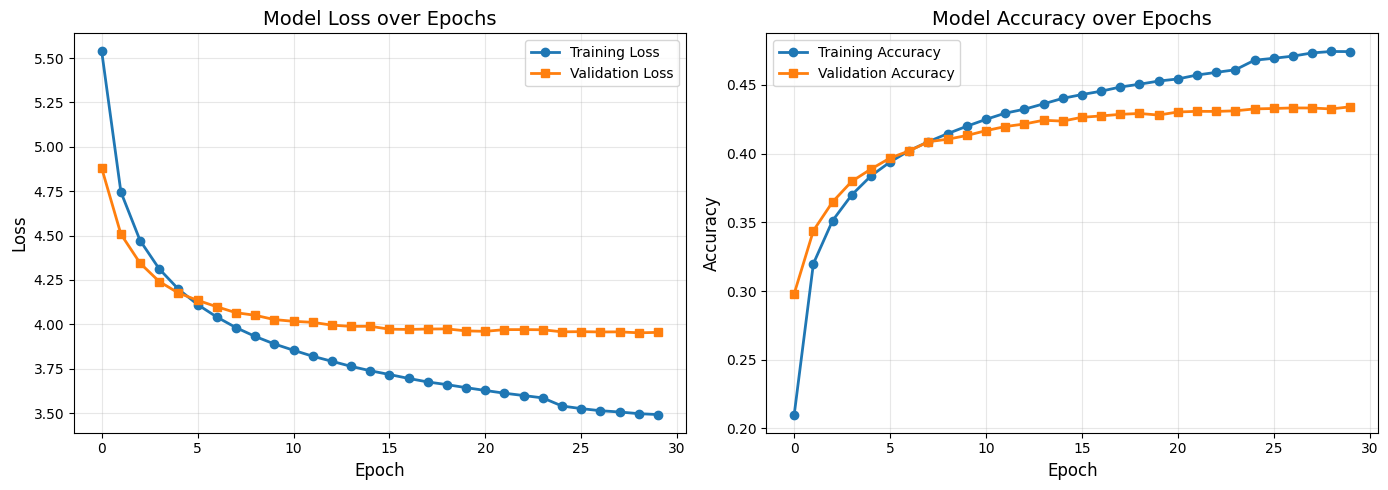

✓ Training plots displayed!

Training Summary:
  Final Training Loss: 3.4921
  Final Validation Loss: 3.9550
  Final Training Accuracy: 0.4742
  Final Validation Accuracy: 0.4340


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Model Loss over Epochs', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Accuracy over Epochs', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training plots displayed!")

# Print training summary
print(f"\nTraining Summary:")
print(f"  Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


In [ ]:
import os
os.listdir("/content")


['.config',
 'image_features_incep.npy',
 'captions_dict.json',
 'Images_all',
 'best_incep_caption.keras',
 '__MACOSX',
 'best_balanced_incep_caption.keras',
 'Clean-5Sentences_withComma.txt',
 'drive',
 'tokenizer.pkl',
 'sample_data']

In [ ]:
import numpy as np
import pickle
import os
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# -------------------------------------------------
# 🔹 Load model & tokenizer
# -------------------------------------------------
model = load_model("/content/best_balanced_incep_caption.keras")
with open("/content/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
max_length = 37
print("✅ Model and tokenizer loaded successfully!")

# -------------------------------------------------
# 🔹 Load InceptionV3 (encoder)
# -------------------------------------------------
def load_inceptionv3_encoder():
    base_model = InceptionV3(weights="imagenet")
    model_new = Model(base_model.input, base_model.layers[-2].output)
    return model_new

inception_model = load_inceptionv3_encoder()
print("✅ InceptionV3 encoder ready.")

# -------------------------------------------------
# 🔹 Extract features
# -------------------------------------------------
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    feature = model.predict(x, verbose=0)
    return feature

# -------------------------------------------------
# 🔹 Greedy caption generation (fast)
# -------------------------------------------------
def generate_caption_greedy(model, tokenizer, photo, max_length):
    in_text = "startseq"
    for i in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = np.pad(seq, (0, max_length - len(seq)), mode="constant")
        seq = np.expand_dims(seq, 0)
        yhat = np.argmax(model.predict([photo, seq], verbose=0))
        word = next((w for w, idx in tokenizer.word_index.items() if idx == yhat), None)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    return in_text.replace("startseq", "").replace("endseq", "").strip()

# -------------------------------------------------
# 🔹 Beam Search caption generation (accurate)
# -------------------------------------------------
def generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width=3):
    start_seq = ["startseq"]
    sequences = [[start_seq, 0.0]]

    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            sequence = tokenizer.texts_to_sequences([seq])[0]
            sequence = np.pad(sequence, (0, max_length - len(sequence)), mode="constant")
            sequence = np.expand_dims(sequence, 0)
            preds = model.predict([photo, sequence], verbose=0)[0]
            top_indices = np.argsort(preds)[-beam_width:]

            for idx in top_indices:
                word = next((w for w, i in tokenizer.word_index.items() if i == idx), None)
                if not word:
                    continue
                candidate = [seq + [word], score + np.log(preds[idx] + 1e-10)]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)
        sequences = ordered[:beam_width]

    best_seq = sequences[0][0]
    final_caption = " ".join(best_seq)
    return final_caption.replace("startseq", "").replace("endseq", "").strip()

# -------------------------------------------------
# 🔹 Test on single image
# -------------------------------------------------
test_img = "/content/Images_all/1000268201_693b08cb0e.jpg"
photo = extract_features(test_img, inception_model).reshape((1, 2048))

caption_greedy = generate_caption_greedy(model, tokenizer, photo, max_length)
caption_beam = generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width=3)

print("\n🖼️ Image:", test_img)
print("⚡ Greedy Caption (Fast):", caption_greedy)
print("🌟 Beam Search Caption (Best):", caption_beam)


✅ Model and tokenizer loaded successfully!
✅ InceptionV3 encoder ready.

🖼️ Image: /content/Images_all/1000268201_693b08cb0e.jpg
⚡ Greedy Caption (Fast): लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की रंग की
🌟 Beam Search Caption (Best): लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की लड़की रंग की


In [ ]:
import json

captions_dict = {}

# Read your cleaned captions file
with open("/content/Clean-5Sentences_withComma.txt", "r", encoding="utf-8") as f:
    for line in f:
        if "," not in line:
            continue
        img_id, caption = line.strip().split(",", 1)
        img_id = img_id.split(".")[0]  # remove .jpg extension
        caption = f"startseq {caption.strip()} endseq"

        if img_id not in captions_dict:
            captions_dict[img_id] = []
        captions_dict[img_id].append(caption)

# Save captions dictionary as JSON
with open("/content/captions_dict.json", "w", encoding="utf-8") as f:
    json.dump(captions_dict, f, ensure_ascii=False, indent=2)

print(f"✅ Captions dictionary saved! Total images: {len(captions_dict)}")


✅ Captions dictionary saved! Total images: 8091


In [ ]:
import numpy as np
import pickle, os
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm

# -------------------------------------------------
# 🔹 Load model & tokenizer
# -------------------------------------------------
model = load_model("/content/best_incep_caption.keras")
with open("/content/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

max_length = 37
print("✅ Model and tokenizer loaded successfully!")

# -------------------------------------------------
# 🔹 Load InceptionV3 Encoder
# -------------------------------------------------
def load_inceptionv3_encoder():
    base_model = InceptionV3(weights="imagenet")
    model_new = Model(base_model.input, base_model.layers[-2].output)
    return model_new

inception_model = load_inceptionv3_encoder()
print("✅ InceptionV3 encoder ready.")

# -------------------------------------------------
# 🔹 Extract image features
# -------------------------------------------------
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    feature = model.predict(x, verbose=0)
    return feature

# -------------------------------------------------
# 🔹 Caption Generation (Greedy)
# -------------------------------------------------
def generate_caption(model, tokenizer, photo, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
        seq = np.expand_dims(seq, 0)
        yhat = np.argmax(model.predict([photo, seq], verbose=0))
        word = next((w for w, idx in tokenizer.word_index.items() if idx == yhat), None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.replace('startseq', '').replace('endseq', '').strip()

# -------------------------------------------------
# 🔹 Caption Generation (Beam Search)
# -------------------------------------------------
def generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width=3):
    start_seq = ['startseq']
    sequences = [[start_seq, 0.0]]

    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            sequence = tokenizer.texts_to_sequences([seq])[0]
            sequence = np.pad(sequence, (0, max_length - len(sequence)), mode='constant')
            sequence = np.expand_dims(sequence, 0)
            preds = model.predict([photo, sequence], verbose=0)[0]
            top_indices = np.argsort(preds)[-beam_width:]

            for idx in top_indices:
                word = next((w for w, i in tokenizer.word_index.items() if i == idx), None)
                if not word:
                    continue
                candidate = [seq + [word], score + np.log(preds[idx] + 1e-10)]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)
        sequences = ordered[:beam_width]

    best_seq = sequences[0][0]
    final_caption = " ".join(best_seq)
    return final_caption.replace("startseq", "").replace("endseq", "").strip()

# -------------------------------------------------
# 🔹 BLEU Score Evaluation
# -------------------------------------------------
def evaluate_model_bleu(model, tokenizer, image_dir, captions_dict, max_length, inception_model, beam_width=3):
    smoothie = SmoothingFunction().method4
    bleu_scores = {'BLEU-1': [], 'BLEU-2': [], 'BLEU-3': [], 'BLEU-4': []}

    for img_id, refs in tqdm(captions_dict.items(), desc="Evaluating BLEU", total=len(captions_dict)):
        img_path = os.path.join(image_dir, img_id + '.jpg')
        if not os.path.exists(img_path):
            continue

        photo = extract_features(img_path, inception_model).reshape((1, 2048))
        pred_caption = generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width)

        # Clean up
        pred_tokens = pred_caption.split()
        reference_tokens = [ref.replace('startseq', '').replace('endseq', '').strip().split() for ref in refs]

        # BLEU scores
        bleu_scores['BLEU-1'].append(sentence_bleu(reference_tokens, pred_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothie))
        bleu_scores['BLEU-2'].append(sentence_bleu(reference_tokens, pred_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie))
        bleu_scores['BLEU-3'].append(sentence_bleu(reference_tokens, pred_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie))
        bleu_scores['BLEU-4'].append(sentence_bleu(reference_tokens, pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie))

    print("\n📊 Average BLEU Scores:")
    for k, v in bleu_scores.items():
        print(f"{k}: {np.mean(v):.4f}")

# -------------------------------------------------
# 🔹 Load captions dictionary (cleaned Hindi captions)
# -------------------------------------------------
# Example structure expected: {"1000268201_693b08cb0e": ["startseq ... endseq", ...]}
import json
with open("/content/captions_dict.json", "r") as f:
    captions_dict = json.load(f)

# -------------------------------------------------
# 🔹 Run BLEU evaluation
# -------------------------------------------------
evaluate_model_bleu(model, tokenizer, "/content/Images_all", captions_dict, max_length, inception_model, beam_width=3)


✅ Model and tokenizer loaded successfully!
✅ InceptionV3 encoder ready.


Evaluating BLEU:   0%|          | 1/8091 [00:06<13:34:19,  6.04s/it]


KeyboardInterrupt: 